### Loadings

In [1]:
# --- Libraries ---
import pandas as pd
import numpy as np

import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

import os 

# --- Configuration ---
wd = r"C:\Users\Alejandro\Documents\MQuEA\TFM\main_code"
os.chdir(wd)

from auxi.data import import_data
import auxi.qreg as fc
import auxi.diagnostics as diags

In [2]:
data = import_data(freq  = "Daily")

c:\Users\Alejandro\Documents\MQuEA\TFM\main_code\auxi\data.py:353: DtypeWarning: Columns (40,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  panel = pd.read_csv(csv_path, index_col=0, parse_dates=True)


In [3]:
# --- Specification ---
x_var     = "GPRD_MA7"
y_var     = "Brent_Return"
quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
controls  = [
    "usd_index_ld",
    "Realized_Volatility",
    "badi_ld",
]

# --- Shared diagnostic settings (used by both qreg and CAViaR) ---
h              = 5
tau_eval       = 0.95
test_start     = "2025-01-01"
test_start_coverage = "2023-01-01"
max_h          = 20
insample_date  = "2022-02-28"
window_size    = 250         # fixed rolling-window length (Alejandro's choice)
eval_taus      = [0.05, 0.50, 0.95]   # tail / median / tail quantiles for rolling pinball

In [4]:
from auxi.caviar import compute_breach_indicators


breach_q = [0.01, 0.99]

# Quantile Regression

### Direct forecasting on returns

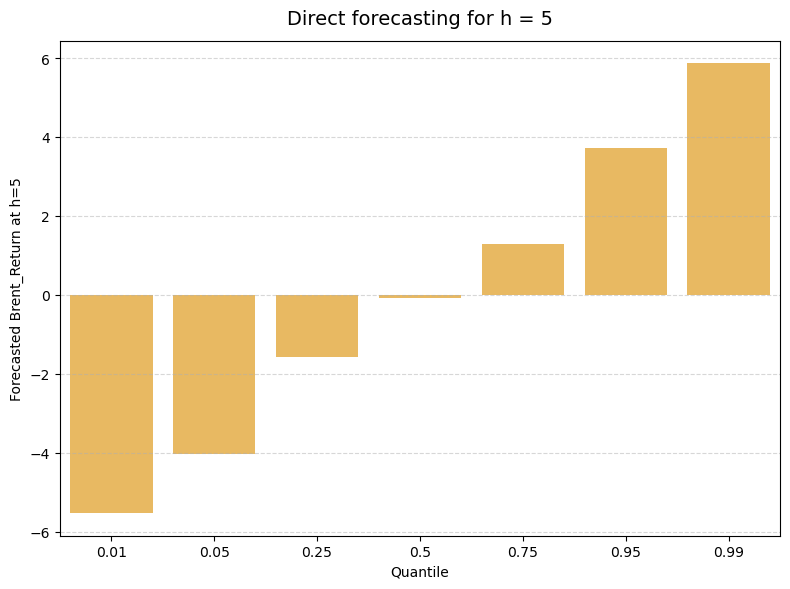

In [5]:
df_1 = fc.direct_forecasting(
    df        = data,
    x         = x_var,
    y         = y_var,
    quantiles = quantiles,
    controls  = controls,
    h         = h,
)

plt.figure(figsize=(8, 6))
plt.title(f"Direct forecasting for h = {h}", fontsize=14, pad=12)
sns.barplot(x=df_1["Quantile"], y=df_1["Forecast"], data=df_1,
            color="orange", alpha=0.7)
plt.xlabel("Quantile")
plt.ylabel(f"Forecasted {y_var} at h={h}")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Density surface (h=5): 100%|██████████| 82/82 [00:06<00:00, 12.74it/s]


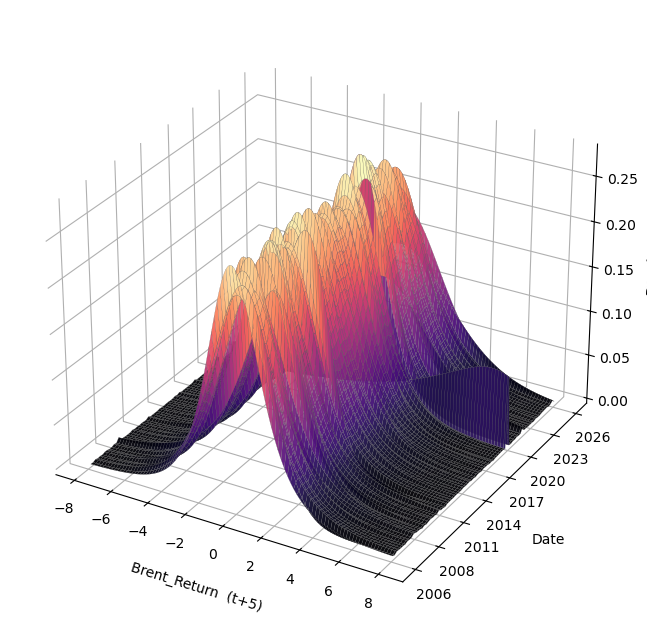

In [4]:
import auxi.predictive_density as pds

surface = pds.density_surface(
    df        = data,
    x         = x_var,
    y         = y_var,
    quantiles = quantiles,
    h         = h,
    controls  = controls,
    freq      = "QE",
)


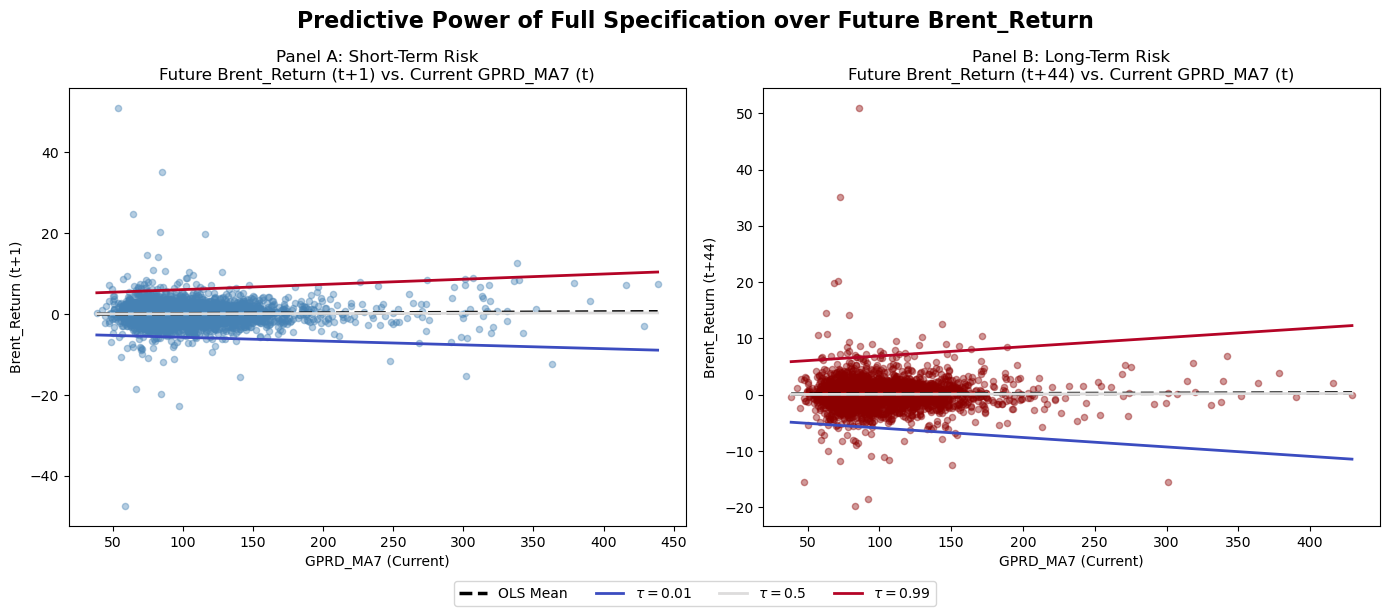

In [10]:
fc.plot_forecasted_scatters(
    df        = data,
    x         = x_var,
    y         = y_var,
    quantiles = [0.01, 0.5, 0.99],
    controls  = controls,
    h_short   = 1,
    h_long    = 44
)

### Pinball loss across horizons 

Rolling evaluation: 100%|██████████| 20/20 [20:31<00:00, 61.57s/it]


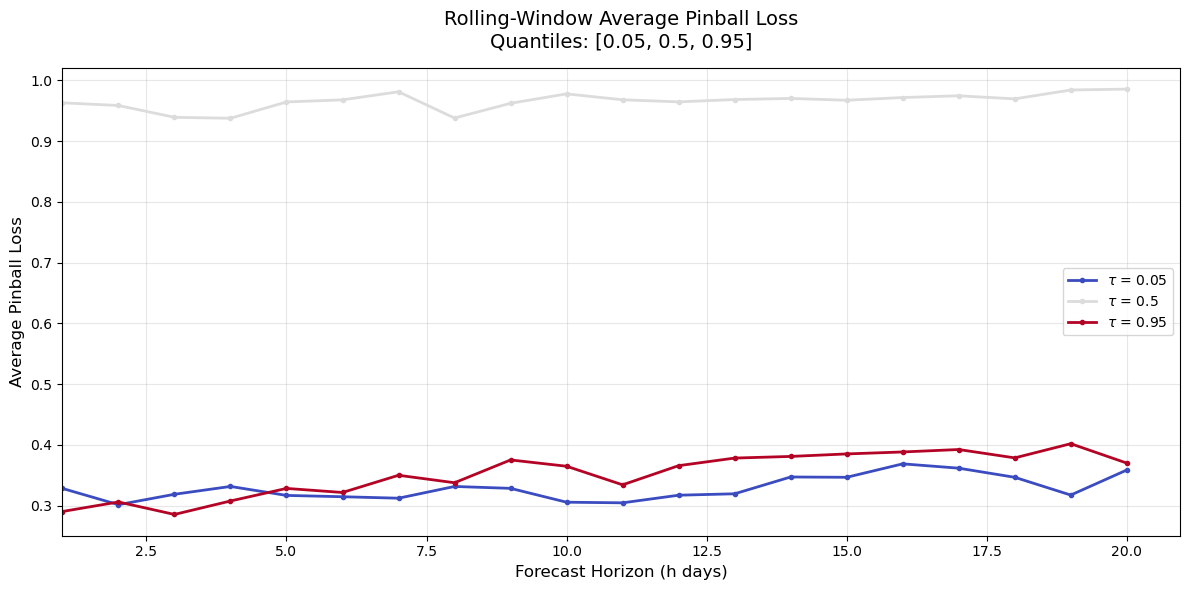

 Tau  Horizon  Avg_Pinball_Loss  N_Forecasts
0.05        2          0.301666          345
0.50        4          0.937489          343
0.95        3          0.285591          344


In [8]:
evaluation_results = diags.compute_rolling_pinball(
    df              = data,
    x               = x_var,
    y               = y_var,
    taus            = eval_taus,
    max_h           = max_h,
    window_size     = window_size,
    test_start_date = test_start,
    controls        = controls,
)

fig = diags.plot_rolling_pinball(evaluation_results)
plt.show()

# Best horizon per quantile (lowest average rolling pinball loss)
best = evaluation_results.loc[
    evaluation_results.groupby("Tau")["Avg_Pinball_Loss"].idxmin()
]
print(best[["Tau", "Horizon", "Avg_Pinball_Loss", "N_Forecasts"]].to_string(index=False))

### Breach / fallout errors 

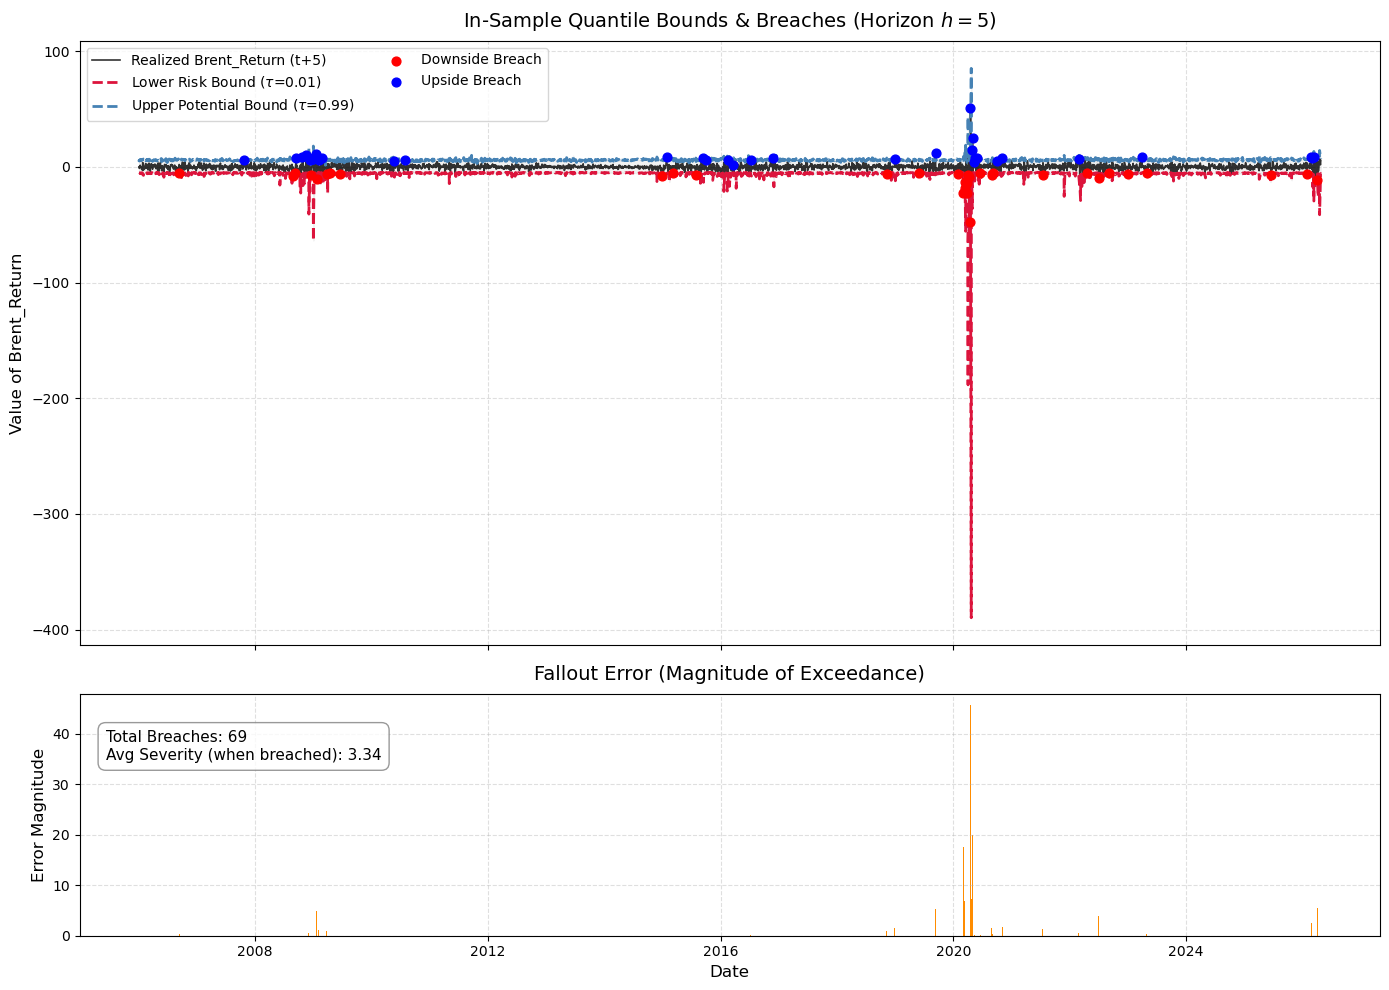

97.83% of the data falls within the predicted quantiles


In [9]:
fallout = diags.plot_fallout_errors(
    df        = data,
    x         = x_var,
    y         = y_var,
    controls  = controls,
    h         = h,
    lower_tau = 0.01,
    upper_tau = 0.99,
)

total_breaches = len(fallout[
    (fallout["Realized"] > fallout["Upper_Bound"]) |
    (fallout["Realized"] < fallout["Lower_Bound"])
])
within_quantiles_ratio = (len(fallout) - total_breaches) / len(fallout)
print(f"{round(within_quantiles_ratio*100, 2)}% of the data falls within the predicted quantiles")

### Kupiec & Christoffersen coverage tests (CAViaR)

In [10]:
# Validation procedure settings (h, tau_eval, test_start, train_frac
# are defined in the shared settings cell above)
val_start     = "2016-01-01"
val_end       = "2022-12-31"
candidate_h   = list(range(1, 91))
retrain_every = 63

Rolling OOS (tau=0.95, h=5): 100%|██████████| 864/864 [01:04<00:00, 13.46it/s]
c:\Users\Alejandro\Documents\MQuEA\TFM\main_code\auxi\diagnostics\direct_forecasting.py:820: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.1%}'.format(v) for v in vals])


Test window: 2023-01-02 -> 2026-04-23
Observations in test set: 864
--- Unified Kupiec POF Test (tau=0.95) ---
Target P(Y < Forecast): 0.9500 (820.8 expected days)
Actual P(Y < Forecast): 0.9387 (811 actual days)
LR Statistic:           2.1893
P-Value:                0.1390
Result: FAIL TO REJECT Null. The model accurately captures the quantile.

p_value for the conditional test is:  0.3055415061291682


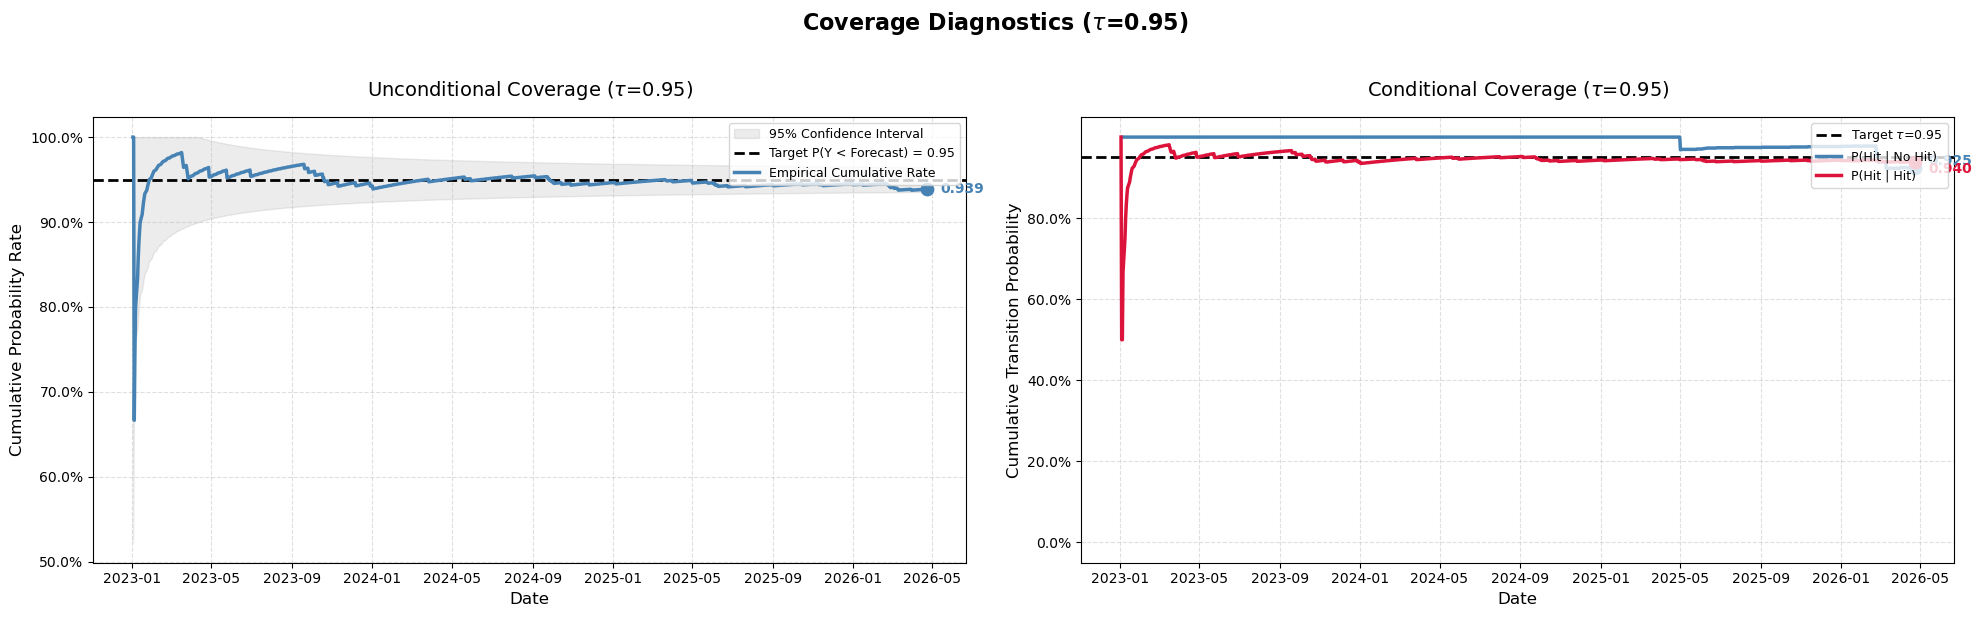

In [11]:
y_oos_actual, y_oos_pred = diags.get_oos_predictions_rolling(
    df              = data,
    x               = x_var,
    y               = y_var,
    tau             = tau_eval,
    h               = h,
    window_size     = window_size,
    test_start_date = test_start_coverage,
    controls        = controls,
)

print(f"Test window: {y_oos_actual.index[0].date()} -> {y_oos_actual.index[-1].date()}")
print(f"Observations in test set: {len(y_oos_actual)}")

# Unconditional coverage (Kupiec POF)
coverage_results = diags.compute_unconditional_coverage_unified(
    realized=y_oos_actual, forecasted=y_oos_pred, tau=tau_eval)

# Conditional coverage (Christoffersen)
cond_coverage_results = diags.compute_conditional_coverage(
    realized=y_oos_actual, forecasted=y_oos_pred, tau=tau_eval)

# Combined coverage dashboard
diags.plot_coverage_dashboard(
    realized=y_oos_actual, forecasted=y_oos_pred, tau=tau_eval)

# CAViaR 
Indicadores de breach CAViaR (Engle & Manganelli, 2004) como regresores adicionales al direct forecasting estandar. Los indicadores se computan **sin lookahead**: para cada fecha $t$, el breach compara el valor realizado $y_t$ con la frontera predicha $h$ pasos antes.

Flujo:
1. `compute_breach_indicators` ajusta las fronteras cuantilicas ($\tau_{low}$, $\tau_{high}$) en el training set a horizonte $h$ y lagea las predicciones.
2. Las columnas `upside_breach` / `downside_breach` se anaden al panel como controles adicionales.
3. `get_oos_predictions_rolling` corre la regresion cuantilica con los indicadores como regresores, refitando en una ventana movil para cada origen del test set.

In [12]:
# 1. Breach indicators (h-aware, sin lookahead)
breach_spec = [x_var] + controls
indicators = compute_breach_indicators(
    df               = data,
    vars_x           = breach_spec,
    vars_y           = y_var,
    h                = h,
    breach_quantiles = breach_q,
    test_start_date  = test_start,
)

print(f"Breach indicators — first {h} rows are NaN (no prior prediction):")
print(indicators.dropna().head(5))
print(f"\nTotal upside breaches:   {int(indicators['upside_breach'].sum())}")
print(f"Total downside breaches: {int(indicators['downside_breach'].sum())}")

Breach indicators — first 5 rows are NaN (no prior prediction):
            upside_breach  downside_breach
Date                                      
2006-01-08            0.0              0.0
2006-01-09            0.0              0.0
2006-01-10            0.0              0.0
2006-01-11            0.0              0.0
2006-01-14            0.0              0.0

Total upside breaches:   36
Total downside breaches: 36


In [13]:
# 2. Augment panel
data_caviar = data.copy(deep=True)
data_caviar["upside_breach"]   = indicators["upside_breach"]
data_caviar["downside_breach"] = indicators["downside_breach"]


In [14]:
caviar_controls = controls + ["upside_breach", "downside_breach"]

### In-sample fit (CAViaR)

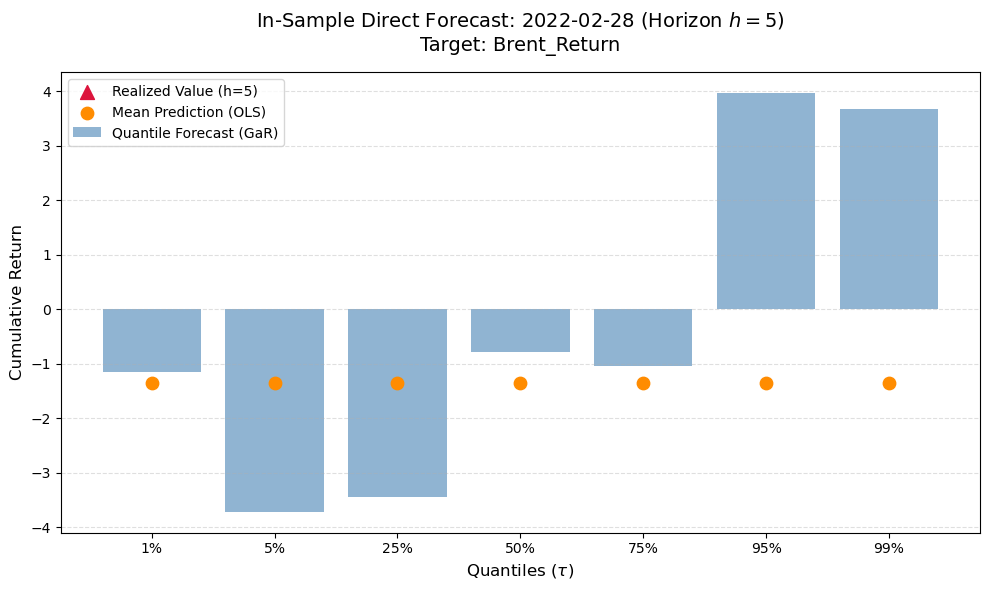

In [15]:
df_caviar_insample = fc.insample_direct_forecasting(
    df             = data_caviar,
    x              = x_var,
    y              = y_var,
    quantiles      = quantiles,
    controls       = caviar_controls,
    train_end_date = insample_date,
    h              = h,
)

### Pinball loss across horizons (CAViaR)

Rolling evaluation: 100%|██████████| 20/20 [13:51<00:00, 41.58s/it]


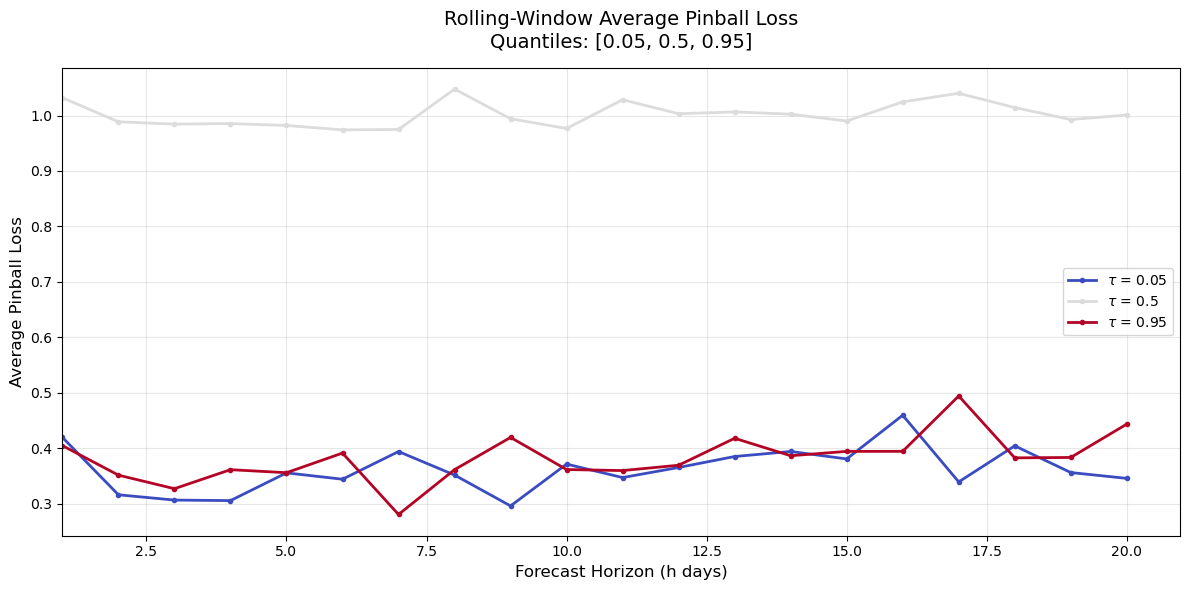

 Tau  Horizon  Avg_Pinball_Loss  N_Forecasts
0.05        9          0.295960          199
0.50        6          0.974174          202
0.95        7          0.280565          201


In [16]:
eval_caviar_i = diags.compute_rolling_pinball(
    df              = data_caviar,
    x               = x_var,
    y               = y_var,
    taus            = eval_taus,
    max_h           = max_h,
    window_size     = window_size,
    test_start_date = test_start,
    controls        = caviar_controls,
)

fig = diags.plot_rolling_pinball(eval_caviar_i)
plt.show()

best_caviar_i = eval_caviar_i.loc[
    eval_caviar_i.groupby("Tau")["Avg_Pinball_Loss"].idxmin()
]
print(best_caviar_i[["Tau", "Horizon", "Avg_Pinball_Loss", "N_Forecasts"]].to_string(index=False))

### Breach / fallout errors (CAViaR)

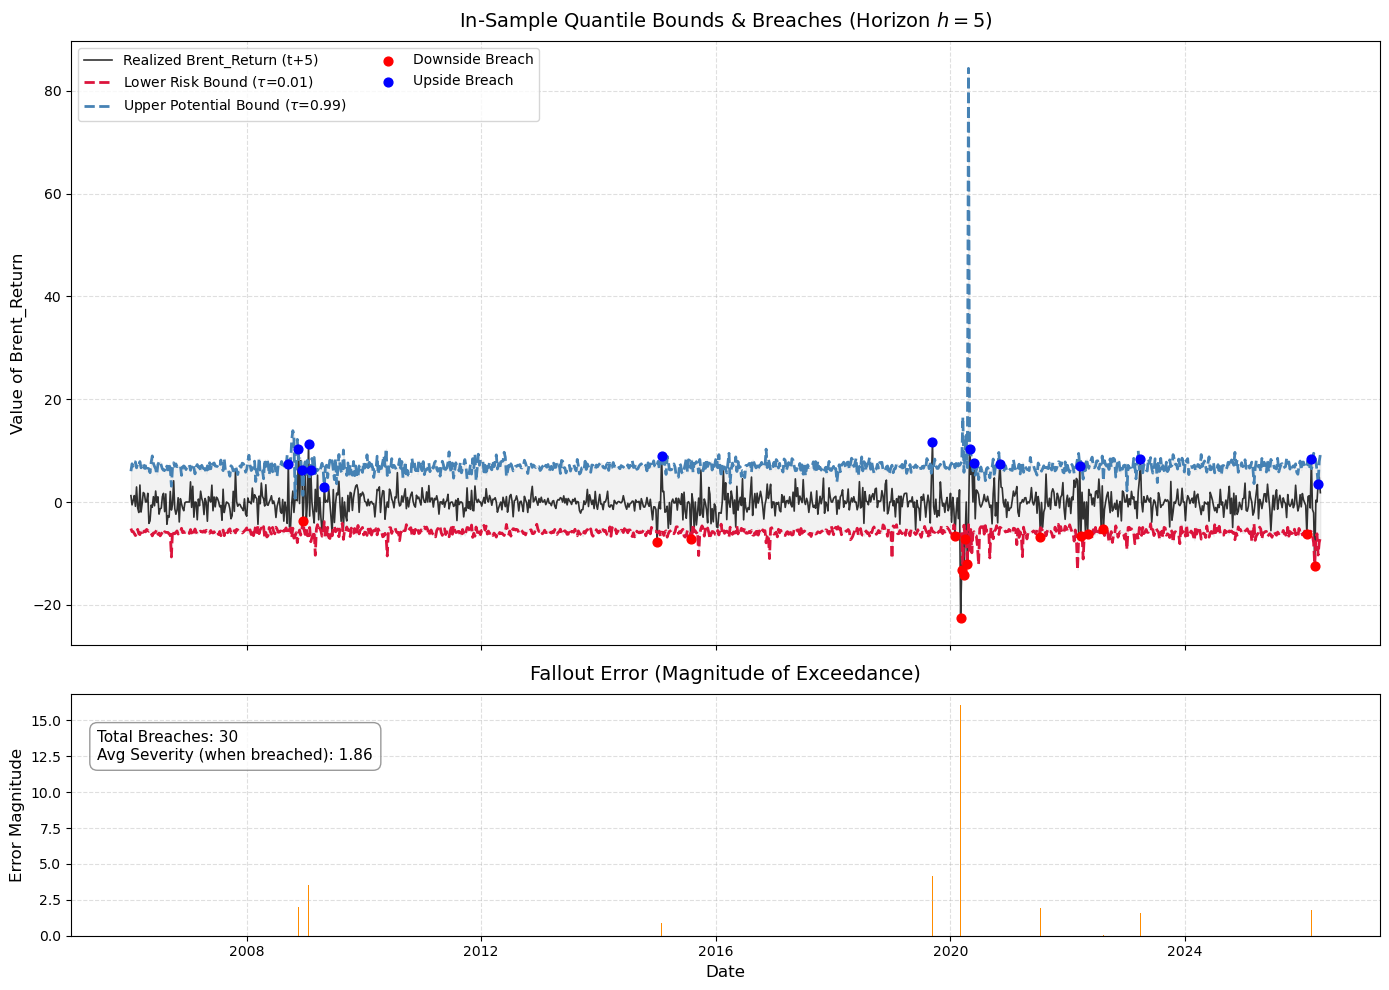

97.17% of the data falls within the predicted quantiles


In [17]:
fallout_caviar = diags.plot_fallout_errors(
    df        = data_caviar,
    x         = x_var,
    y         = y_var,
    controls  = caviar_controls,
    h         = h,
    lower_tau = 0.01,
    upper_tau = 0.99,
)

total_breaches_caviar = len(fallout_caviar[
    (fallout_caviar["Realized"] > fallout_caviar["Upper_Bound"]) |
    (fallout_caviar["Realized"] < fallout_caviar["Lower_Bound"])
])
within_ratio_caviar = (len(fallout_caviar) - total_breaches_caviar) / len(fallout_caviar)
print(f"{round(within_ratio_caviar*100, 2)}% of the data falls within the predicted quantiles")

### Kupiec & Christoffersen coverage tests (CAViaR)

Rolling OOS (tau=0.95, h=5): 100%|██████████| 517/517 [00:49<00:00, 10.42it/s]
c:\Users\Alejandro\Documents\MQuEA\TFM\main_code\auxi\diagnostics\direct_forecasting.py:820: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.1%}'.format(v) for v in vals])


Test window: 2023-01-02 -> 2026-04-20
Observations in test set: 517
--- Unified Kupiec POF Test (tau=0.95) ---
Target P(Y < Forecast): 0.9500 (491.1 expected days)
Actual P(Y < Forecast): 0.9381 (485 actual days)
LR Statistic:           1.4366
P-Value:                0.2307
Result: FAIL TO REJECT Null. The model accurately captures the quantile.

p_value for the conditional test is:  0.3759122499547197


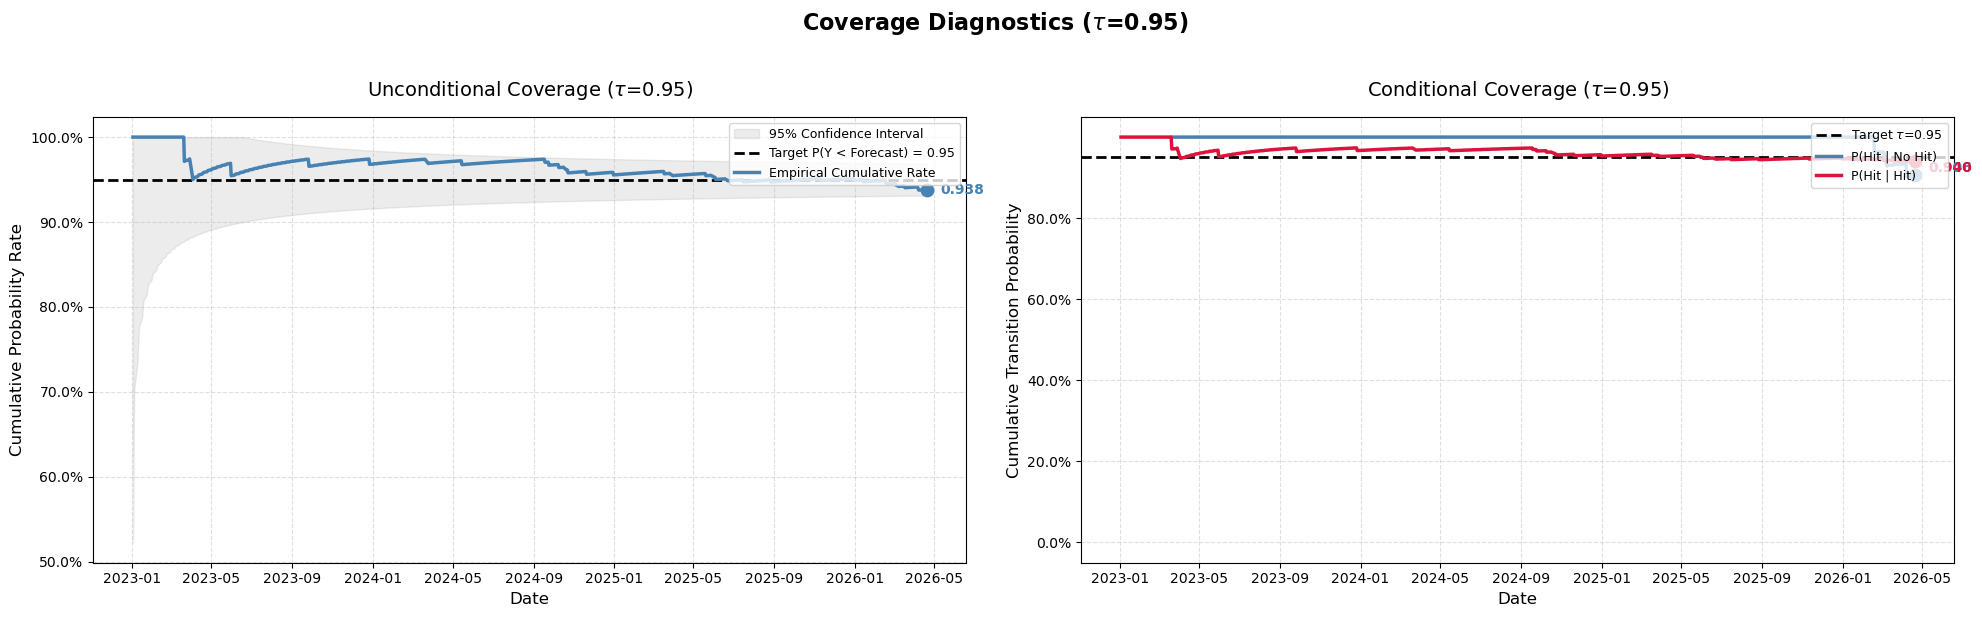

In [18]:
y_caviar_actual, y_caviar_pred = diags.get_oos_predictions_rolling(
    df              = data_caviar,
    x               = x_var,
    y               = y_var,
    tau             = tau_eval,
    h               = h,
    window_size     = window_size,
    test_start_date = test_start_coverage,
    controls        = caviar_controls,
)

print(f"Test window: {y_caviar_actual.index[0].date()} -> {y_caviar_actual.index[-1].date()}")
print(f"Observations in test set: {len(y_caviar_actual)}")

# Unconditional coverage (Kupiec POF)
coverage_caviar = diags.compute_unconditional_coverage_unified(
    realized=y_caviar_actual, forecasted=y_caviar_pred, tau=tau_eval)

# Conditional coverage (Christoffersen)
cond_coverage_caviar = diags.compute_conditional_coverage(
    realized=y_caviar_actual, forecasted=y_caviar_pred, tau=tau_eval)

# Combined coverage dashboard
diags.plot_coverage_dashboard(
    realized=y_caviar_actual, forecasted=y_caviar_pred, tau=tau_eval)

# CAViaR (severity)
Variante de severidad de los indicadores de breach CAViaR (Engle & Manganelli, 2004). En lugar de variables binarias (0/1), se usan las distancias absolutas entre el valor realizado y la frontera cuantílica violada:

  $\text{upside\_severity}_t   = \max(0,\; y_t - Q_{high}(y_t \mid x_{t-h})) \geq 0$
  $\text{downside\_severity}_t = \max(0,\; Q_{low}(y_t  \mid x_{t-h}) - y_t) \geq 0$

Las fronteras se ajustan **sin lookahead** (misma mecánica que CAViaR indicador).

In [19]:
from auxi.caviar import compute_breach_severity_indicators

# 1. Severity indicators (h-aware, no lookahead)
severity_spec = [x_var] + controls
severity_indicators = compute_breach_severity_indicators(
    df               = data,
    vars_x           = severity_spec,
    vars_y           = y_var,
    h                = h,
    breach_quantiles = breach_q,
    test_start_date  = test_start,
)

print(f"Severity indicators — first {h} rows are NaN (no prior prediction):")
print(severity_indicators.dropna().describe())
print(f"\nNon-zero upside severities:   {(severity_indicators['upside_severity'] > 0).sum()}")
print(f"Non-zero downside severities: {(severity_indicators['downside_severity'] > 0).sum()}")

Severity indicators — first 5 rows are NaN (no prior prediction):
       upside_severity  downside_severity
count      3180.000000        3180.000000
mean          0.035335           0.038593
std           0.906859           0.816500
min           0.000000           0.000000
25%           0.000000           0.000000
50%           0.000000           0.000000
75%           0.000000           0.000000
max          45.437220          37.947911

Non-zero upside severities:   36
Non-zero downside severities: 36


In [20]:
# 2. Augment panel
data_caviar_s = data.copy(deep=True)
data_caviar_s["upside_severity"]   = severity_indicators["upside_severity"]
data_caviar_s["downside_severity"] = severity_indicators["downside_severity"]

In [21]:
caviar_s_controls = controls + ["upside_severity", "downside_severity"]

### In-sample fit (CAViaR severity)

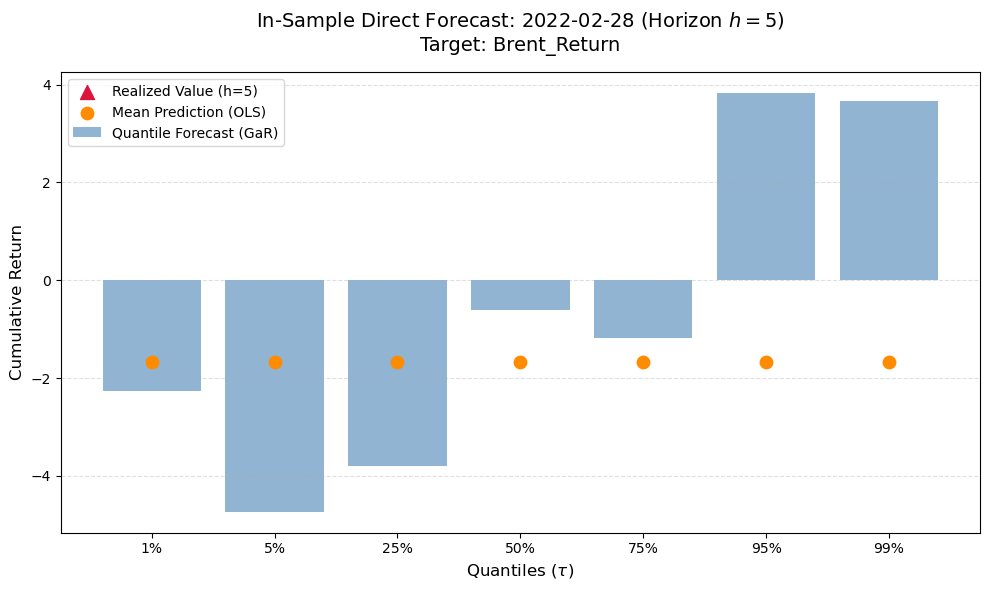

In [22]:
df_caviar_s_insample = fc.insample_direct_forecasting(
    df             = data_caviar_s,
    x              = x_var,
    y              = y_var,
    quantiles      = quantiles,
    controls       = caviar_s_controls,
    train_end_date = insample_date,
    h              = h,
)

### Pinball loss across horizons (CAViaR severity)

Rolling evaluation: 100%|██████████| 20/20 [15:07<00:00, 45.36s/it]


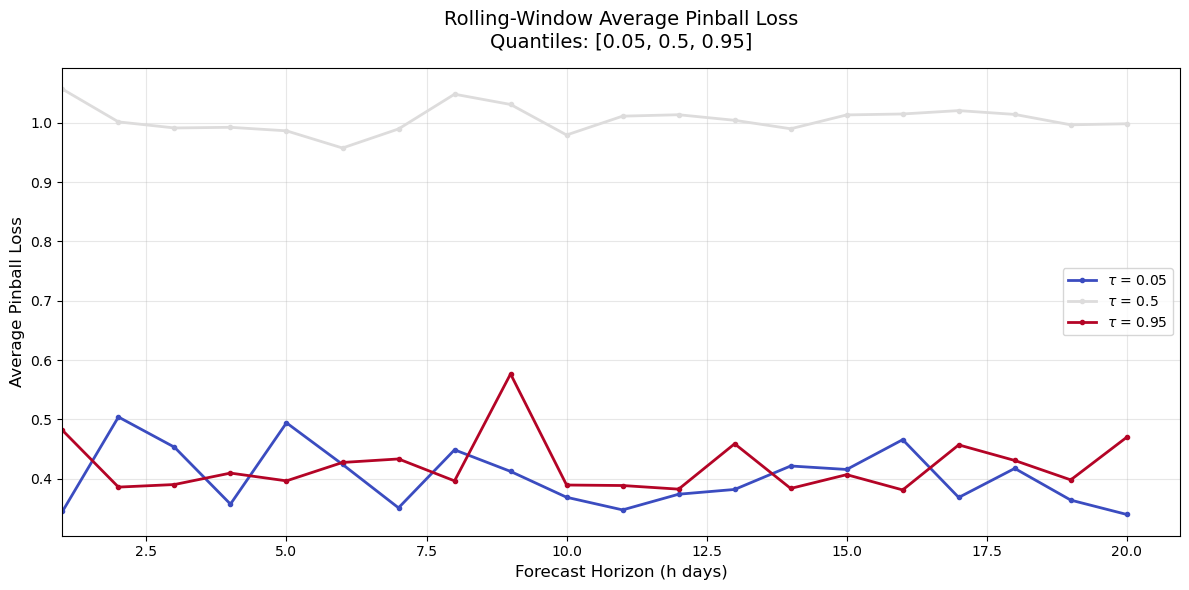

 Tau  Horizon  Avg_Pinball_Loss  N_Forecasts
0.05       20          0.339677          188
0.50        6          0.957302          202
0.95       16          0.380996          192


In [23]:
eval_caviar_s = diags.compute_rolling_pinball(
    df              = data_caviar_s,
    x               = x_var,
    y               = y_var,
    taus            = eval_taus,
    max_h           = max_h,
    window_size     = window_size,
    test_start_date = test_start,
    controls        = caviar_s_controls,
)

fig = diags.plot_rolling_pinball(eval_caviar_s)
plt.show()

best_caviar_s = eval_caviar_s.loc[
    eval_caviar_s.groupby("Tau")["Avg_Pinball_Loss"].idxmin()
]
print(best_caviar_s[["Tau", "Horizon", "Avg_Pinball_Loss", "N_Forecasts"]].to_string(index=False))

### Breach / fallout errors (CAViaR severity)

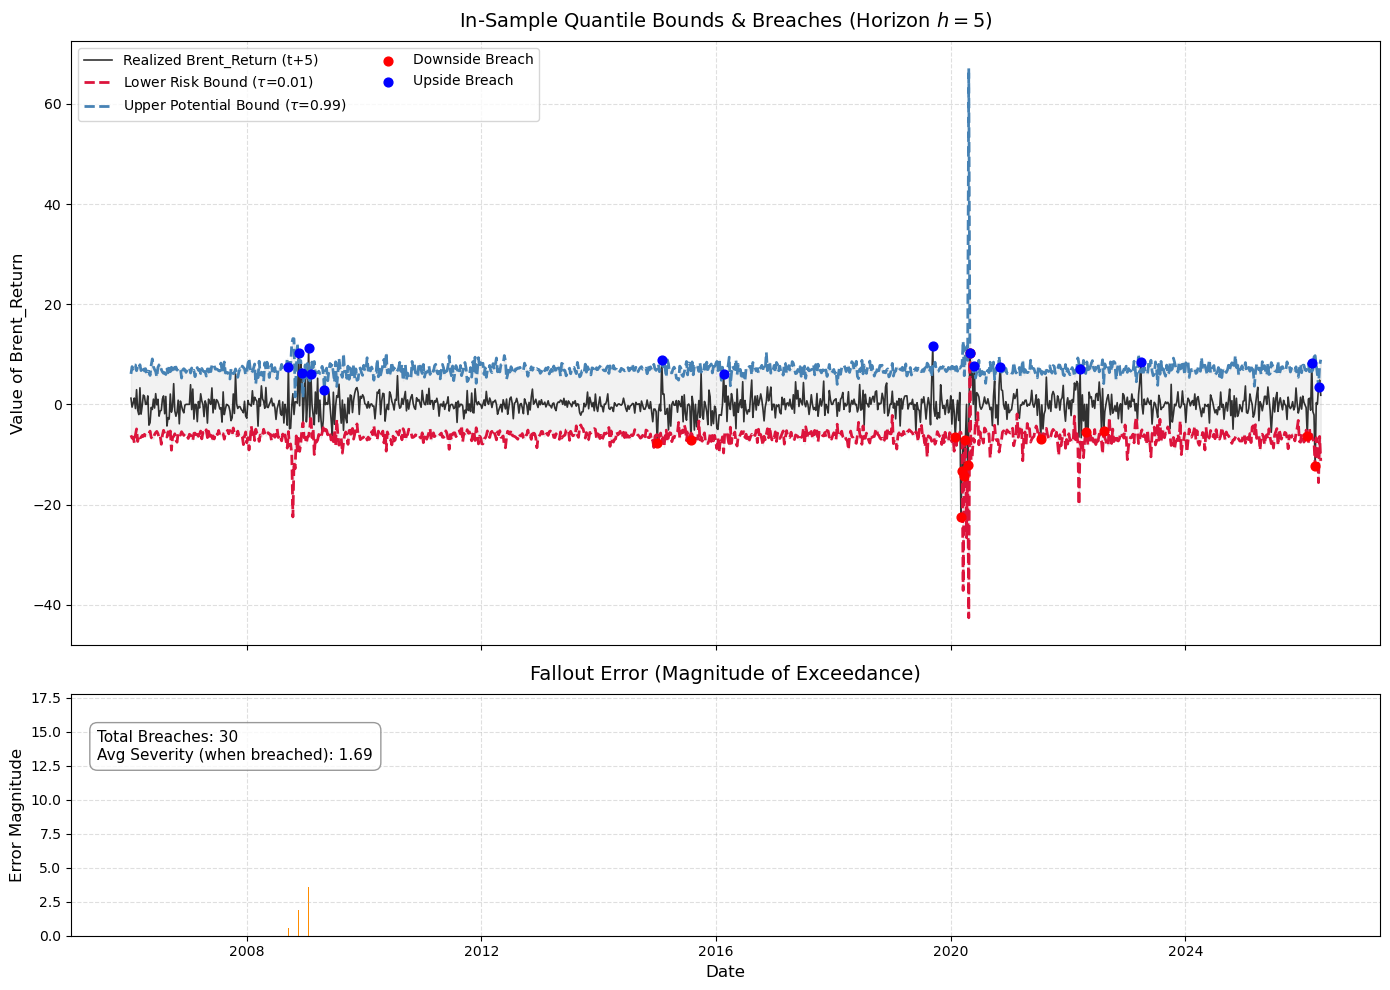

97.26% of the data falls within the predicted quantiles


In [24]:
fallout_caviar_s = diags.plot_fallout_errors(
    df        = data_caviar_s,
    x         = x_var,
    y         = y_var,
    controls  = caviar_s_controls,
    h         = h,
    lower_tau = 0.01,
    upper_tau = 0.99,
)

total_breaches_caviar_s = len(fallout_caviar_s[
    (fallout_caviar_s["Realized"] > fallout_caviar_s["Upper_Bound"]) |
    (fallout_caviar_s["Realized"] < fallout_caviar_s["Lower_Bound"])
])
within_ratio_caviar_s = (len(fallout_caviar_s) - total_breaches_caviar_s) / len(fallout_caviar_s)
print(f"{round(within_ratio_caviar_s*100, 2)}% of the data falls within the predicted quantiles")

### Kupiec & Christoffersen coverage tests (CAViaR severity)

Rolling OOS (tau=0.95, h=5): 100%|██████████| 517/517 [00:54<00:00,  9.48it/s]
c:\Users\Alejandro\Documents\MQuEA\TFM\main_code\auxi\diagnostics\direct_forecasting.py:820: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.1%}'.format(v) for v in vals])


Test window: 2023-01-02 -> 2026-04-20
Observations in test set: 517
--- Unified Kupiec POF Test (tau=0.95) ---
Target P(Y < Forecast): 0.9500 (491.1 expected days)
Actual P(Y < Forecast): 0.9342 (483 actual days)
LR Statistic:           2.4714
P-Value:                0.1159
Result: FAIL TO REJECT Null. The model accurately captures the quantile.

p_value for the conditional test is:  0.24699731917762946


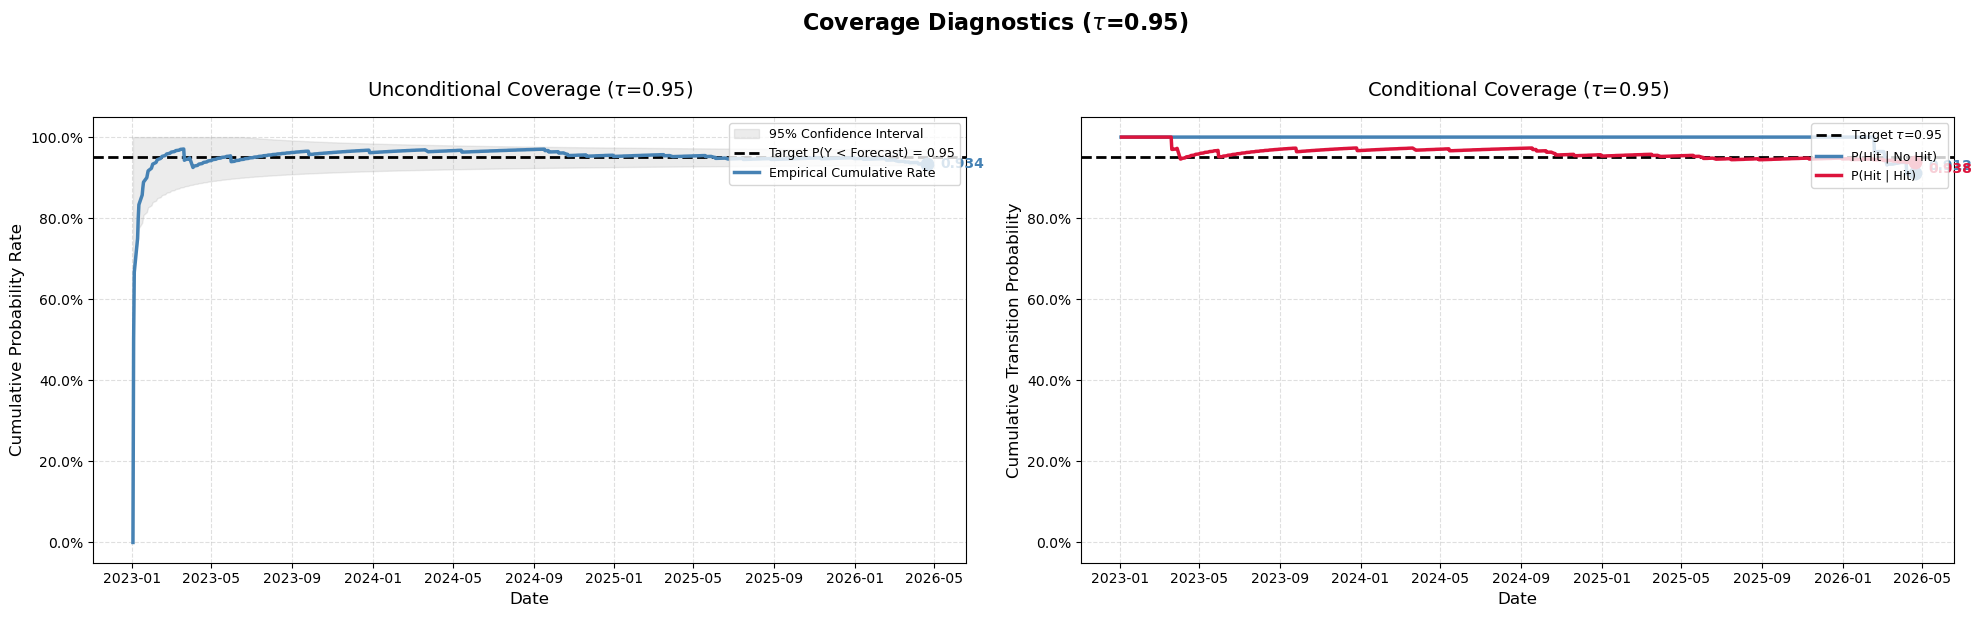

In [25]:
y_caviar_s_actual, y_caviar_s_pred = diags.get_oos_predictions_rolling(
    df              = data_caviar_s,
    x               = x_var,
    y               = y_var,
    tau             = tau_eval,
    h               = h,
    window_size     = window_size,
    test_start_date = test_start_coverage,
    controls        = caviar_s_controls,
)

print(f"Test window: {y_caviar_s_actual.index[0].date()} -> {y_caviar_s_actual.index[-1].date()}")
print(f"Observations in test set: {len(y_caviar_s_actual)}")

# Unconditional coverage (Kupiec POF)
coverage_caviar_s = diags.compute_unconditional_coverage_unified(
    realized=y_caviar_s_actual, forecasted=y_caviar_s_pred, tau=tau_eval)

# Conditional coverage (Christoffersen)
cond_coverage_caviar_s = diags.compute_conditional_coverage(
    realized=y_caviar_s_actual, forecasted=y_caviar_s_pred, tau=tau_eval)

# Combined coverage dashboard
diags.plot_coverage_dashboard(
    realized=y_caviar_s_actual, forecasted=y_caviar_s_pred, tau=tau_eval)

# Model comparison

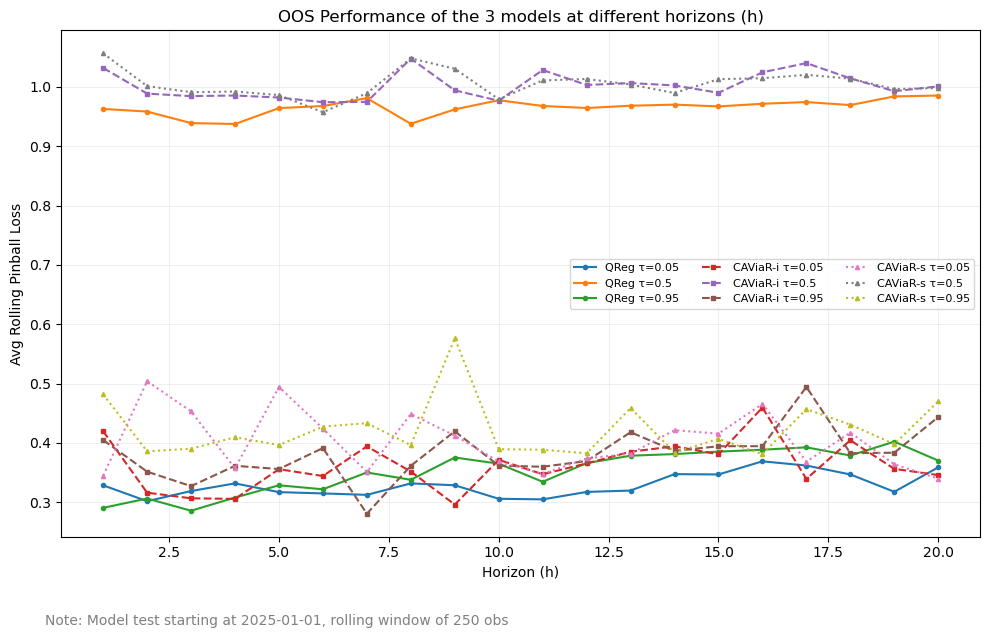

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("OOS Performance of the 3 models at different horizons (h)")

for tau in eval_taus:
    subset = evaluation_results[evaluation_results["Tau"] == tau]
    plt.plot(subset["Horizon"], subset["Avg_Pinball_Loss"],
             label=f"QReg τ={tau}", linestyle="-", marker="o", markersize=3)

for tau in eval_taus:
    subset = eval_caviar_i[eval_caviar_i["Tau"] == tau]
    plt.plot(subset["Horizon"], subset["Avg_Pinball_Loss"],
             label=f"CAViaR-i τ={tau}", linestyle="--", marker="s", markersize=3)

for tau in eval_taus:
    subset = eval_caviar_s[eval_caviar_s["Tau"] == tau]
    plt.plot(subset["Horizon"], subset["Avg_Pinball_Loss"],
             label=f"CAViaR-s τ={tau}", linestyle=":", marker="^", markersize=3)

plt.xlabel("Horizon (h)")
plt.ylabel("Avg Rolling Pinball Loss")
plt.legend(fontsize=8, ncol=3)
plt.grid(alpha=0.2)

plt.figtext(
    0.05, -0.05,
    f"Note: Model test starting at {test_start}, rolling window of {window_size} obs",
    ha="left", fontsize=10, color="gray"
)

plt.tight_layout()
plt.show()

### Diebold-Mariano test for equal predictive accuracy

Pairwise comparison of the three direct-forecasting models using the asymmetric tick loss as the loss function. The DM statistic uses a rectangular-kernel HAC variance with bandwidth $h-1$, matching the known $MA(h-1)$ autocorrelation structure of $h$-step direct forecast errors (Diebold & Mariano, 1995). P-values from the Student-$t(P-1)$ distribution.

**Interpretation of Alpha:** $\alpha = \bar{d} = \overline{L_1 - L_2}$. If $\alpha < 0$ and significant, Model 1 has lower average loss (is better). If $\alpha > 0$ and significant, Model 2 is better.

In [27]:
# Collect rolling OOS predictions (all at tau_eval, h from settings cell)
dm_models = {
    "Standard": y_oos_pred,
    "CAViaR-i": y_caviar_pred,
    "CAViaR-s": y_caviar_s_pred,
}

error_table, dm_table = diags.compute_dm_comparison(
    models=dm_models,
    realized=y_oos_actual,
    tau=tau_eval,
    h=h,
)

print(f"=== Error Metrics (tau={tau_eval}, h={h}) ===")
print(error_table.to_string(index=False))
print(f"\n=== Diebold-Mariano Pairwise Tests (tau={tau_eval}, h={h}) ===")
print(dm_table.to_string(index=False))

=== Error Metrics (tau=0.95, h=5) ===
   Model     RMSE     MAPE  Avg_Tick_Loss
Standard 4.227603 892.1912       0.238001
CAViaR-i 4.039112 901.8586       0.228991
CAViaR-s 4.594325 901.2513       0.331721

=== Diebold-Mariano Pairwise Tests (tau=0.95, h=5) ===
 Model_1  Model_2    Alpha  t_stat  p_value Significance
Standard CAViaR-i  0.00901  0.9085   0.3640             
Standard CAViaR-s -0.09372 -1.0814   0.2800             
CAViaR-i CAViaR-s -0.10273 -1.1834   0.2372             
